### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from utils import * 
from FAPT import * 

In [2]:
import sympy as sy
import numpy as np
import scipy.linalg as scipy_linalg
import qutip as qt

# ------------------------------------------------------------------
# 1. Äußerer Code: Symbolische Vorberechnung (Einmalige Ausführung)
# ------------------------------------------------------------------
def prepare_floquet_functions(
    pulse_shape_builder, p_names, s, rH, rW,
    include_geometric=True, include_micromotion=True, include_g_correction=True, verbose=True
):
    """Berechnet Heff, W und M_sym symbolisch und erzeugt schnell auswertbare NumPy-Lambdas."""
    t_sym = sy.Symbol("t", real=True)
    p_syms = [sy.Symbol(name, real=True) for name in p_names]
    
    if verbose: print("1/2 Erstelle symbolischen Puls & berechne W und Heff ...")
    A_expr, wd_expr = pulse_shape_builder(t_sym, p_syms)
    
    orig_np_exp = np.exp
    np.exp = sy.exp
    try:
        W = W_Floquet_elements_fast(rW, wd_expr, s.resonances, s.E_array, s.V1_dressed_array, A=A_expr, V0=None, analytics=True, verbose=True)
        Heff = Heff_Floquet_total_matrix_summed(
            rH, wd_expr, A_expr, s.resonances, s.E_array, s.V1_dressed_array, V0=None, ref_state=None,
            dwd=wd_expr.diff(t_sym), dA=A_expr.diff(t_sym), t=t_sym, analytics=True, rW=rW,
            include_geometric=include_geometric, include_micromotion=include_micromotion,
            include_g_correction=include_g_correction, W=W, verbose = verbose
        )
    finally:
        np.exp = orig_np_exp
    
    resonances = dict(s.resonances) if isinstance(s.resonances, list) else s.resonances
    D, d_res, kref = len(s.E_array), len(resonances), min(resonances)

    M_sym = sy.zeros(D, d_res)
    for r in range(0, rW + 1):
        for l in range(D):
            for idx_a, a in enumerate(resonances):
                for p, (W_lp_a, _, _) in W[r, l, a].items():
                    M_sym[l, idx_a] += sy.exp(-sy.I * (s.E_array[kref] + p * wd_expr) * t_sym) * W_lp_a

    if verbose: print("2/2 Erzeuge Lambdified H_func und M_func ...")
    args_list = [t_sym] + p_syms
    return (
        sy.lambdify(args_list, sy.Matrix(Heff).doit(), modules=['numpy', 'scipy']),
        sy.lambdify(args_list, M_sym.doit(), modules=['numpy', 'scipy'])
    )


# ------------------------------------------------------------------
# 2. Hilfsfunktionen: Vektorisierte H-Auswertung & Infidelity
# ------------------------------------------------------------------
def _eval_H_stack(H_func, t_mids, p_vals, d_res):
    try:
        H_all = np.asarray(H_func(t_mids, *p_vals), dtype=complex)
        if H_all.shape == (d_res, d_res, len(t_mids)):
            return H_all
    except Exception:
        pass
    H_all = np.empty((d_res, d_res, len(t_mids)), dtype=complex)
    for k, t_mid in enumerate(t_mids):
        H_all[:, :, k] = np.array(H_func(t_mid, *p_vals), dtype=complex).reshape(d_res, d_res)
    return H_all


def compute_pulse_infidelity(
    p_vals, H_func, M_func, t_mids, dt, tg, D, d_res, res_indices, ind_a, ind_b, state_a, state_b, target_metric, qobj_ideal=None
):
    H_all = _eval_H_stack(H_func, t_mids, p_vals, d_res)

    U_eff = np.eye(d_res, dtype=complex)
    for k in range(len(t_mids)):
        U_eff = scipy_linalg.expm(-1j * H_all[:, :, k] * dt) @ U_eff

    M_final = np.array(M_func(tg, *p_vals), dtype=complex).reshape(D, d_res)
    U_total = M_final @ U_eff
    norms = np.linalg.norm(U_total, axis=0)
    U_total /= norms

    if target_metric == "population":
        fidelity = 0.5 * (np.abs(U_total[state_b, ind_a])**2 + np.abs(U_total[state_a, ind_b])**2)
    elif target_metric == "process":
        fidelity = qt.process_fidelity(qt.Qobj(U_total[res_indices, :]), qobj_ideal)

    return 1.0 - fidelity


# ------------------------------------------------------------------
# 3. Entschlackte Parameter-Sweep Methode
# ------------------------------------------------------------------
from scipy.optimize import differential_evolution

from scipy.optimize import differential_evolution

from time import perf_counter
import numpy as np
import scipy.linalg as scipy_linalg
from scipy.optimize import differential_evolution


def optimize_pulse_parameters(
    H_func,
    M_func,
    param_ranges,
    s,
    tg,
    N_t=200,
    target_metric="population",
    verbose=True,
    popsize=15,
    maxiter=80,
    tol=1e-5,
    polish=True,
    mutation=(0.5, 1.0),
    recombination=0.7,
    seed=1,
    workers=1,
):
  tlist = np.linspace(0, tg, N_t)
  dt, t_mids = tlist[1] - tlist[0], tlist[:-1] + (tlist[1] - tlist[0]) / 2.0

  p_names = list(param_ranges.keys())
  bounds = [(np.min(param_ranges[p]), np.max(param_ranges[p])) for p in p_names]

  resonances = (
      dict(s.resonances) if isinstance(s.resonances, list) else s.resonances
  )
  D, d_res, res_indices = len(s.E_array), len(resonances), list(resonances.keys())
  ind_a, ind_b = res_indices.index(s.state_a), res_indices.index(s.state_b)

  qobj_ideal = None
  if target_metric == "process":
    U_ideal = np.eye(d_res, dtype=complex)
    if d_res >= 2:
      U_ideal[ind_a, ind_b], U_ideal[ind_b, ind_a] = 1j, 1j
      U_ideal[ind_a, ind_a], U_ideal[ind_b, ind_b] = 0, 0
    qobj_ideal = qt.Qobj(U_ideal)

  n_calls = 0
  best_so_far = float("inf")
  t_start = perf_counter()

  # --- DEBUG 1: SETUP ---
  print("=" * 60)
  print("[DEBUG] Starte Puls-Optimierung")
  print(f"[DEBUG] Parameter ({len(p_names)}): {p_names}")
  print(
      f"[DEBUG] Hilbertraum D={D}, Reduzierter Raum d_res={d_res}, N_t={N_t}"
  )
  print(
      f"[DEBUG] Popsize={popsize} -> {popsize * len(p_names)} Evall. pro"
      f" Generation | Maxiter={maxiter} | Workers={workers}"
  )
  print("=" * 60)

  def objective(x):
    nonlocal n_calls, best_so_far
    n_calls += 1
    val = compute_pulse_infidelity(
        tuple(x),
        H_func,
        M_func,
        t_mids,
        dt,
        tg,
        D,
        d_res,
        res_indices,
        ind_a,
        ind_b,
        s.state_a,
        s.state_b,
        target_metric,
        qobj_ideal,
    )

    if val < best_so_far:
      best_so_far = val

    return val

  def callback(xk, convergence):
    """Callback pro Generation in differential_evolution."""
    elapsed = perf_counter() - t_start
    print(
        f"[DEBUG Gen Callback] Aufrufe: {n_calls:6d} | Bisher beste Infidelity:"
        f" {best_so_far:.6e} | Conv: {convergence:.4e} | Zeit: {elapsed:.2f}s"
    )

  print("[DEBUG] Starte differential_evolution...")
  result = differential_evolution(
      objective,
      bounds=bounds,
      strategy="best1bin",
      popsize=popsize,
      mutation=mutation,
      recombination=recombination,
      maxiter=maxiter,
      tol=tol,
      polish=False,  # Polish wird manuell getrackt, siehe unten
      updating="deferred",
      workers=workers,
      disp=verbose,
      seed=seed,
      callback=callback,
  )

  # --- DEBUG 2: POLISH PHASE ---
  if polish:
    print(
        f"\n[DEBUG] Haupt-Optimierung fertig nach {n_calls} Aufrufen. Starte"
        f" L-BFGS-B Polish (kann bei vielen Parametern hängen)..."
    )
    t_polish = perf_counter()
    n_calls_before_polish = n_calls

    # Nachoptimierung manuell ausführen, um festzustellen ob es HIER hängt
    from scipy.optimize import minimize

    res_polish = minimize(
        objective,
        result.x,
        method="L-BFGS-B",
        bounds=bounds,
        tol=tol,
    )
    if res_polish.fun < result.fun:
      result = res_polish

    print(
        f"[DEBUG] Polish abgeschlossen in"
        f" {perf_counter() - t_polish:.2f}s (+{n_calls - n_calls_before_polish} Aufrufe)"
    )

  best_p_vals = tuple(result.x)
  best_params, best_infidelity = dict(zip(p_names, best_p_vals)), result.fun

  # --- DEBUG 3: FINAL DYNAMICS ---
  print("\n[DEBUG] Berechne finale Trajektorie (best_psi_t)...")
  t_sim = perf_counter()

  c_eff, best_psi_t = np.zeros(d_res, dtype=complex), np.zeros(
      (D, N_t), dtype=complex
  )
  c_eff[ind_a] = 1

  for i, t in enumerate(tlist):
    best_psi_t[:, i] = (
        np.asarray(M_func(t, *best_p_vals), dtype=complex).reshape(D, d_res)
        @ c_eff
    )
    if i != N_t - 1:
      H = np.asarray(H_func(t + dt / 2, *best_p_vals), dtype=complex).reshape(
          d_res, d_res
      )
      c_eff = scipy_linalg.expm(-1j * H * dt) @ c_eff

  print(
      f"[DEBUG] Finale Trajektorie fertig in {perf_counter() - t_sim:.2f}s."
      f" Gesamtdauer: {perf_counter() - t_start:.2f}s"
  )
  print("=" * 60)

  if verbose:
    print(
        f"\nFunktionsaufrufe : {n_calls}\nInfidelity      "
        f" : {best_infidelity:.6e}\nBeste Parameter:"
    )
    for k, v in best_params.items():
      print(f"  {k:15s}: {v:.10g}")

  return best_params, best_infidelity, best_psi_t, tlist

In [3]:
from dataclasses import dataclass
import itertools
from pathlib import Path
from typing import Sequence
import numpy as np
import sympy as sp


@dataclass(frozen=True)
class PulseFitParams:
  A_r: sp.Expr
  A_i: sp.Expr
  dwd: sp.Expr
  wd0: float


def load_fit_params(
    tg: float,
    sigma_ratio: float,
    pulse_type: str = "gauss",
    fit_dir: str | Path = "operational_res/fit_data",
) -> PulseFitParams:
  file_path = (
      Path(fit_dir)
      / f"fit_params_{pulse_type}_tg_{round(tg)}ns_sigma_{sigma_ratio:.1f}.npz"
  )
  if not file_path.is_file():
    raise FileNotFoundError(f"Keine Fit-Datei unter '{file_path}' gefunden.")

  with np.load(file_path) as data:
    return PulseFitParams(
        A_r=sp.sympify(str(data["A_r_expr"])),
        A_i=sp.sympify(str(data["A_i_expr"])),
        dwd=sp.sympify(str(data["dwd_expr"])),
        wd0=float(data["wd0"]),
    )


def _substitute_time_symbol(expr: sp.Expr, target_t: sp.Symbol) -> sp.Expr:
  free_syms = expr.free_symbols
  if not free_syms:
    return expr
  t_candidate = next((s for s in free_syms if s.name == "t"), next(iter(free_syms)))
  return expr.subs(t_candidate, target_t)


def _generate_monomial_basis(
    base_funcs: dict[str, sp.Expr], t_sym: sp.Symbol, max_order: int
) -> tuple[list[sp.Expr], list[str]]:
  components = {}
  for key, expr in base_funcs.items():
    components[key] = expr
    components[f"d{key}"] = sp.diff(expr, t_sym)

  comp_keys = list(components.keys())
  comp_exprs = list(components.values())

  basis_exprs, basis_names = [], []

  for total_deg in range(1, max_order + 1):
    for powers in itertools.product(range(total_deg + 1), repeat=len(comp_keys)):
      if sum(powers) == total_deg:
        monomial_expr = sp.Mul(*[
            expr**p for expr, p in zip(comp_exprs, powers) if p > 0
        ])
        name_parts = []
        for k, p in zip(comp_keys, powers):
          if p == 1:
            name_parts.append(k)
          elif p > 1:
            name_parts.append(f"{k}pow{p}")
        monomial_name = "_".join(name_parts)

        basis_exprs.append(monomial_expr)
        basis_names.append(monomial_name)

  return basis_exprs, basis_names


def fitted_pulse_with_offset(
    t_sym: sp.Symbol,
    coeffs: dict[str, sp.Symbol | float] | tuple | list,
    tg: float,
    sigma_ratio: float,
    max_order: int = 1,
    whitelist: Sequence[str] | None = None,
    pulse_type: str = "gauss",
    fit_dir: str | Path = "operational_res/fit_data",
) -> tuple[sp.Expr, sp.Expr]:
  """Baut A_expr und wd_expr auf.

  Nicht-gewhitelistete Selbstbeiträge (c_ar_Ar, c_ai_Ai, c_dwd_dwd) werden automatisch auf 1.0 gesetzt.
  Nicht-gewhitelistete Kopplungsterme werden automatisch auf 0.0 gesetzt.
  """
  raw = load_fit_params(
      tg=tg, sigma_ratio=sigma_ratio, pulse_type=pulse_type, fit_dir=fit_dir
  )

  base_funcs = {
      "Ar": _substitute_time_symbol(raw.A_r, t_sym),
      "Ai": _substitute_time_symbol(raw.A_i, t_sym),
      "dwd": _substitute_time_symbol(raw.dwd, t_sym),
  }

  basis_exprs, basis_names = _generate_monomial_basis(
      base_funcs, t_sym, max_order=max_order
  )

  wl = set(whitelist) if whitelist is not None else None

  # Zuordnung der Parameterliste falls coeffs als List/Tuple übergeben wird
  coeffs_dict = {}
  if isinstance(coeffs, (tuple, list)):
    param_keys = []
    if wl is None or "c_dwd_offset" in wl:
      param_keys.append("c_dwd_offset")

    for name in basis_names:
      for prefix in ("c_ar_", "c_ai_", "c_dwd_"):
        key = f"{prefix}{name}"
        if wl is None or key in wl:
          param_keys.append(key)

    coeffs_dict = dict(zip(param_keys, coeffs))
  elif isinstance(coeffs, dict):
    coeffs_dict = coeffs

  A_r_total = sp.S.Zero
  A_i_total = sp.S.Zero
  dwd_total = sp.S.Zero

  # Frequenz-Offset
  if wl is None or "c_dwd_offset" in wl:
    dwd_total += coeffs_dict.get("c_dwd_offset", 0.0)

  for expr, name in zip(basis_exprs, basis_names):
    c_ar_key = f"c_ar_{name}"
    c_ai_key = f"c_ai_{name}"
    c_dwd_key = f"c_dwd_{name}"

    # 1. In-Phase (A_r)
    is_ar_self = name == "Ar"
    if wl is None or c_ar_key in wl:
      val = coeffs_dict.get(c_ar_key, 1.0 if is_ar_self else 0.0)
    else:
      val = 1.0 if is_ar_self else 0.0
    if val != 0:
      A_r_total += val * expr

    # 2. Quadratur (A_i)
    is_ai_self = name == "Ai"
    if wl is None or c_ai_key in wl:
      val = coeffs_dict.get(c_ai_key, 1.0 if is_ai_self else 0.0)
    else:
      val = 1.0 if is_ai_self else 0.0
    if val != 0:
      A_i_total += val * expr

    # 3. Detuning (dwd)
    is_dwd_self = name == "dwd"
    if wl is None or c_dwd_key in wl:
      val = coeffs_dict.get(c_dwd_key, 1.0 if is_dwd_self else 0.0)
    else:
      val = 1.0 if is_dwd_self else 0.0
    if val != 0:
      dwd_total += val * expr

  A_expr = A_r_total + sp.I * A_i_total
  wd_expr = raw.wd0 + dwd_total

  return A_expr, wd_expr


def get_param_ranges(
    tg: float,
    sigma_ratio: float,
    max_order: int = 1,
    whitelist: Sequence[str] | None = None,
    pulse_type: str = "gauss",
    fit_dir: str | Path = "operational_res/fit_data",
    deriv_base_range: tuple[float, float] = (1.0, 30),
    deriv_other_range: tuple[float, float] = (-0.1, 0.1),
) -> dict[str, tuple[float, float]]:
  """Generiert dynamisch Parametergrenzen für die Whitelist.

  Unterscheidet dabei zwischen Standard-Monom-Koeffizienten und
  Ableitungs-Koeffizienten.
  """
  raw = load_fit_params(
      tg=tg, sigma_ratio=sigma_ratio, pulse_type=pulse_type, fit_dir=fit_dir
  )
  dummy_t = sp.Symbol("t")
  base_funcs = {
      "Ar": _substitute_time_symbol(raw.A_r, dummy_t),
      "Ai": _substitute_time_symbol(raw.A_i, dummy_t),
      "dwd": _substitute_time_symbol(raw.dwd, dummy_t),
  }

  _, basis_names = _generate_monomial_basis(
      base_funcs, dummy_t, max_order=max_order
  )

  wl = set(whitelist) if whitelist is not None else None
  ranges = {}

  if wl is None or "c_dwd_offset" in wl:
    ranges["c_dwd_offset"] = (-0.005, 0.005)

  for name in basis_names:
    # Prüfen, ob der Monom-Name eine Ableitung enthält (z. B. "dAr", "d2Ai")
    is_deriv = any(
        part.startswith("d") and part[1:] in base_funcs
        for part in name.split("_")
    )

    keys_and_defaults = [
        (f"c_ar_{name}", 1.0 if name == "Ar" else 0.0),
        (f"c_ai_{name}", 1.0 if name == "Ai" else 0.0),
        (f"c_dwd_{name}", 1.0 if name == "dwd" else 0.0),
    ]

    for key, default_val in keys_and_defaults:
      if wl is None or key in wl:
        if is_deriv:
          # Eigene Ranges für Ableitungsterme
          ranges[key] = (
              deriv_base_range if default_val == 1.0 else deriv_other_range
          )
        else:
          # Standard Ranges für reguläre Monome
          ranges[key] = (0.8, 1.2) if default_val == 1.0 else (-0.2, 0.2)

  return ranges

# Optimization use

In [ ]:
s = Simulation()
rH = 2
rW = 1
tg, sigma_ratio = 250.0, 0.3
pulse = 'gauss'
whitelist = [
    # Hauptdiagonale (Skalierungsfaktoren)
    "c_ar_Ar",  # In-Phase Amplitude (A_r)
    # "c_ai_Ai",  # Quadratur Amplitude (A_i)
    "c_dwd_dwd",  # Detuning-Amplitude (dwd)
    # Physikalische Kreuzkopplungen (z. B. DRAG & Stark-Shift)
    "c_dwd_dAr",  # DRAG-Term: Ableitung von A_r schoppt in die Quadratur A_i
    # "c_dwd_ddwd",
    # "c_dwd_Arpow2",  # Stark-Shift höherer Ordnung: ~ A_r^2 (aus max_order=2)
    ]

# Dynamische Parametergrenzen auflösen (Standardmäßig für max_order=1)
param_ranges = get_param_ranges(tg=tg, sigma_ratio=sigma_ratio, max_order=1, whitelist=whitelist)
print("params: ", param_ranges)
# 1. Einmalige symbolische Vorberechnung von H_func und M_func
H_func, M_func = prepare_floquet_functions(
    pulse_shape_builder=lambda t, p: fitted_pulse_with_offset(t, p, tg=tg, sigma_ratio=sigma_ratio, pulse_type=pulse, whitelist=whitelist),
    p_names=list(param_ranges.keys()),
    s=s,
    rH=rH,
    rW=rW,
    include_geometric=True,
    include_micromotion=True,
    include_g_correction=True,
    verbose=False
)

params:  {'c_dwd_ddwd': (-0.1, 0.1), 'c_dwd_dwd': (0.8, 1.2), 'c_ar_Ar': (0.8, 1.2)}


W-Floquet order r=1/1: 100%|██████████| 81/81 [00:00<00:00, 291.17it/s]


✅ W-elements calculation completed.


In [ ]:
# --- Setup für schnelle Konvergenz ---
best_p, best_infid, best_psi_t, tlist = optimize_pulse_parameters(
    H_func=H_func,
    M_func=M_func,
    param_ranges=param_ranges,
    s=s,
    tg=tg,
    N_t=100,
    target_metric="population",
    verbose=True,
    
    # Tuning für Tempo & Fokus:
    popsize=6,              # Reduziert von 15 auf 8-10 (spart massiv Funktionsaufrufe pro Generation)
    maxiter=20,             # Reicht bei schneller Konvergenz meist aus
    tol=1e-8,               # Frühzeitiges Stoppen (L-BFGS-B poliert den Rest)
    mutation=(0.2, 0.6),    # Engere Suchschritte
    recombination=0.9,      # Aggressivere Rekombination
    polish=True,            # WICHTIG: polish macht die Fein-Arbeit am Ende superschnell!
    workers=1,              # Ermöglicht immediate updating
)

[DEBUG] Starte Puls-Optimierung
[DEBUG] Parameter (3): ['c_dwd_ddwd', 'c_dwd_dwd', 'c_ar_Ar']
[DEBUG] Hilbertraum D=27, Reduzierter Raum d_res=3, N_t=100
[DEBUG] Popsize=6 -> 18 Evall. pro Generation | Maxiter=20 | Workers=1
[DEBUG] Starte differential_evolution...
differential_evolution step 1: f(x)= 0.1255224001886044
[DEBUG Gen Callback] Aufrufe:     36 | Bisher beste Infidelity: 1.255224e-01 | Conv: 6.1695e-05 | Zeit: 14.24s
differential_evolution step 2: f(x)= 0.12539142999262465
[DEBUG Gen Callback] Aufrufe:     54 | Bisher beste Infidelity: 1.253914e-01 | Conv: 4.8709e-04 | Zeit: 21.28s
differential_evolution step 3: f(x)= 0.12523221890012648
[DEBUG Gen Callback] Aufrufe:     72 | Bisher beste Infidelity: 1.252322e-01 | Conv: 4.2213e-03 | Zeit: 28.26s
differential_evolution step 4: f(x)= 0.12517410046459831
[DEBUG Gen Callback] Aufrufe:     90 | Bisher beste Infidelity: 1.251741e-01 | Conv: 1.4002e-02 | Zeit: 35.26s
differential_evolution step 5: f(x)= 0.12517410046459831
[DEBUG

<>:51: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:51: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/7k/3h2gl4fs7gb1hdzh7fl2mc940000gn/T/ipykernel_11848/1127841463.py:51: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax2.set(xlabel="Time $t$ [ns]", ylabel="Population $|\psi(t)|^2$", ylim=(-0.02, 1.02))


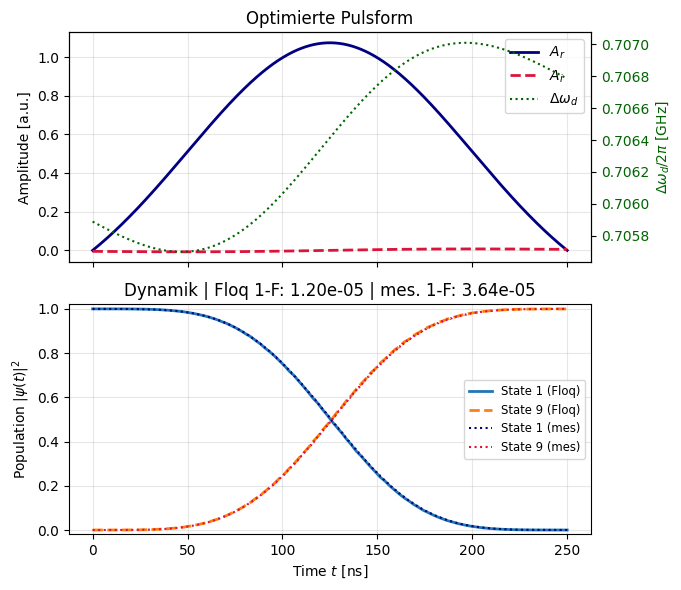

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sy

# 1. Setup & SymPy Auswertung
N_t, t_mes = 1001, np.linspace(0, tg, 1001)
t_sym, p_syms = sy.Symbol("t", real=True), [sy.Symbol(k, real=True) for k in param_ranges]

A_ex, wd_ex = fitted_pulse_with_offset(t_sym, p_syms, tg, sigma_ratio=sigma_ratio, max_order=1, whitelist=whitelist)
A_f, wd_f = sy.lambdify([t_sym] + p_syms, A_ex, ["numpy", "scipy"]), sy.lambdify([t_sym] + p_syms, wd_ex, ["numpy", "scipy"])

p_vals = tuple(best_p[k] for k in param_ranges)
A_t, wd_t = A_f(t_mes, *p_vals), wd_f(t_mes, *p_vals)
Ar, Ai = np.real(A_t), np.imag(A_t)

q_sig = lambda t, args=None: float(Ar[i := min(int(t / tg * 1000), 1000)] * np.cos(wd_t[i] * t) + Ai[i] * np.sin(wd_t[i] * t))

# 2. Mesolve-Dynamik
H = [s.H0, [s.V1, q_sig]]
res_keys = list(s.resonances.keys() if isinstance(s.resonances, dict) else dict(s.resonances).keys())
ia, ib = res_keys.index(s.state_a), res_keys.index(s.state_b)
amp_a, amp_b = resonant_subspace_column_evolution(H, t_mes, ia, debug=False, s=s), resonant_subspace_column_evolution(H, t_mes, ib, debug=False, s=s)
infid_mes = 1.0 - 0.5 * (np.abs(amp_a[ib, -1])**2 + np.abs(amp_b[ia, -1])**2)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# Pulsshapes
ax1.plot(t_mes, Ar, label=r"$A_r$", color="navy", lw=2)
ax1.plot(t_mes, Ai, label=r"$A_i$", color="crimson", lw=2, ls="--")
ax1_d = ax1.twinx()
ax1_d.plot(t_mes, wd_t / (2 * np.pi), label=r"$\Delta\omega_d$", color="darkgreen", lw=1.5, ls=":")
ax1_d.set_ylabel(r"$\Delta\omega_d / 2\pi$ [GHz]", color="darkgreen")
ax1_d.tick_params(axis="y", labelcolor="darkgreen")
ax1.set(ylabel="Amplitude [a.u.]", title="Optimierte Pulsform")
l1, l2 = ax1.get_legend_handles_labels()
l3, l4 = ax1_d.get_legend_handles_labels()
ax1.legend(l1 + l3, l2 + l4, loc="upper right")
ax1.grid(True, alpha=0.3)

# Dynamik (Floquet vs. mesolve)
curves = [
    (tlist, np.abs(best_psi_t[s.state_a])**2, f"State {s.state_a} (Floq)", "tab:blue", "-", 2),
    (tlist, np.abs(best_psi_t[s.state_b])**2, f"State {s.state_b} (Floq)", "tab:orange", "--", 2),
    (t_mes, np.abs(amp_a[ia])**2, f"State {s.state_a} (mes)", "navy", ":", 1.5),
    (t_mes, np.abs(amp_a[ib])**2, f"State {s.state_b} (mes)", "crimson", ":", 1.5),
]
for x, y, lbl, col, ls, lw in curves:
    ax2.plot(x, y, label=lbl, color=col, ls=ls, lw=lw)

ax2.set(xlabel="Time $t$ [ns]", ylabel="Population $|\psi(t)|^2$", ylim=(-0.02, 1.02))
ax2.set_title(f"Dynamik | Floq 1-F: {best_infid:.2e} | mes. 1-F: {infid_mes:.2e}")
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=True, fontsize="small", loc="center right")

plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle
import numpy as np
import sympy as sy

# 1. Parameter definieren
tg_val = tg
fit_dir = "operational_res/fit_data_gauss"

output_dir = "operational_res/final_forms"
os.makedirs(output_dir, exist_ok=True)

tg_int = int(round(tg_val))
filename = f"pulse_shape_sigma_{sigma_ratio:.1f}_tg_{tg_int}ns.pkl"
filepath = os.path.join(output_dir, filename)

# 2. Builder mit den konkreten tg- und sigma-Werten (greift auf operational_res/fit_data_gauss zu)
t_sym = sy.Symbol("t", real=True)
p_names = list(best_p.keys())
p_syms = [sy.Symbol(name, real=True) for name in p_names]

A_expr_sym, wd_expr_sym = fitted_pulse_with_offset(t_sym, p_syms, tg=tg_val, sigma_ratio=sigma_ratio)

# Optimierte Parameter durch konkrete Best-Values ersetzen
param_substitutions = [(p_sym, best_p[name]) for p_sym, name in zip(p_syms, p_names)]

A_expr_opt = A_expr_sym.subs(param_substitutions)
wd_expr_opt = wd_expr_sym.subs(param_substitutions)

# 3. Fit-Parameter direkt aus operational_res/fit_data_gauss laden
popt_real, popt_imag, popt_freq, freq_model = load_fit_params(tg_val, sigma_ratio, fit_dir=fit_dir)

saved_data = {
    "metadata": {
        "sigma": sigma_ratio,
        "tg": tg_val,
        "best_infidelity": best_infid,
        "freq_model": str(freq_model),
        "fit_dir": fit_dir,
    },
    "best_parameters": best_p,
    "fit_parameters": {
        "popt_real": popt_real,
        "popt_imag": popt_imag,
        "popt_freq": popt_freq,
    },
    "sympy_expressions": {
        "A_t": A_expr_opt,
        "wd_t": wd_expr_opt,
        "t_symbol": t_sym,
    },
    "simulation_data": {
        "tlist": tlist,
        "best_psi_t": best_psi_t,
    }
}

# 4. Speichern via Pickle
with open(filepath, "wb") as f:
    pickle.dump(saved_data, f)

print(f"✅ Ergebnisse erfolgreich gespeichert unter:\n   {filepath}")
print(f"   Infidelity: {best_infid:.6e}")

FileNotFoundError: Keine Fit-Datei unter 'operational_res/fit_data_gauss/fit_params_gauss_tg_250ns_sigma_0.3.npz' gefunden.